Nome: Paulo Santos do Nascimento Filho

RA: 186629

Curso: Engenharia de Computação (AB) - 34

# Ex03 - Transformações de Intensidade (operações radiométricas)

Esta atividade tem 2 objetivos principais: 
  - Entender o que são transformações radiométricas e como podem ser implementadas
  - Explorar duas aplicações para as transformações radiométricas: normalização e segmentação. 

In [182]:
# Importando as bibliotecas que serão utilizadas
import os

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image

In [183]:
def download_image(url:str) -> str:
    filename = os.path.basename(url)

    if os.path.exists(filename):
        return filename

    response = requests.get(url)

    with open(filename, mode="wb") as file:
        file.write(response.content)

    return filename

## Parte 1 - Manipulando imagens

O código abaixo baixa e lê a imagem *flower.pgm* utilizando a biblioteca PIL/pillow, apresenta a imagem na tela e a transforma num array numpy.

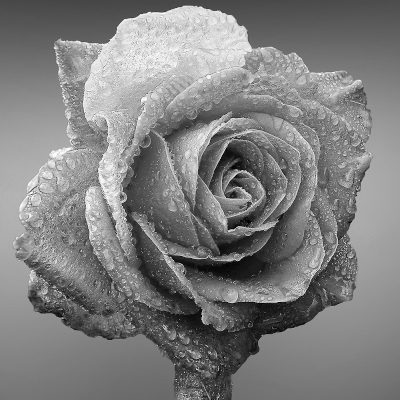

[[ 72  72  72 ...  78  77  77]
 [ 73  72  73 ...  78  78  78]
 [ 73  73  74 ...  78  78  79]
 ...
 [118 117 116 ... 107 107 106]
 [116 115 115 ... 106 106 106]
 [116 116 115 ... 106 106 106]]


In [184]:
url = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/flower.pgm"
img_file = download_image(url)
img = Image.open(img_file)
display(img)

# Convertendo para um array do numpy
f=np.asarray(img)
print(f)

É bastante útil poder transformar Images em PIL em arrays numpy, e vice-versa. Isso permitirá que realizemos operações matriciais nas imagens e posteriormente possamos visualizar (e salvar em arquivos) as imagens processadas. 

### Exercício 1.1 

**a)** Classifique a imagem como monocromática (binária, grayscale) ou multibanda (tentando identificar o padrão multibanda adotado). Descubra: qual a profundidade da imagem? Qual o maior e o menor valor de intensidade de pixel da imagem (da imagem, não o teórico da profundidade)? Utilize para isso a biblioteca NumPy.

In [185]:
import numpy as np

# 1. Verificando as dimensões da imagem (para classificar)
print(f"Formato do array (shape): {f.shape}")

# 2. Verificando o tipo de dado (para saber a profundidade)
print(f"Tipo de dado (dtype): {f.dtype}")

# 3. Calculando o maior e menor valor de intensidade da imagem
val_min = np.min(f)
val_max = np.max(f)

print(f"Menor valor na imagem: {val_min}")
print(f"Maior valor na imagem: {val_max}")

Formato do array (shape): (400, 400)
Tipo de dado (dtype): uint8
Menor valor na imagem: 0
Maior valor na imagem: 253


**1. Classificação da Imagem:**
A imagem é **monocromática (Grayscale / em tons de cinza)**.  
*Justificativa:* O formato do array é (400, 400), ou seja, possui apenas duas dimensões (altura e largura), indicando que há apenas um canal de intensidade. Se fosse multibanda (como RGB), o formato seria (400, 400, 3). Além disso, não é uma imagem binária, pois possui múltiplos valores intermediários (de 0 até 253), e não apenas preto (0) e branco (255).

**2. Profundidade da imagem:**
A profundidade é de **8 bits**.  
*Justificativa:* O tipo de dado retornado foi uint8 (inteiro sem sinal de 8 bits), o que significa que a imagem suporta teoricamente até 256 níveis de intensidade (de 0 a 255).

**3. Maior e menor valor de intensidade da imagem:**
*   **Menor valor:** 0 (preto absoluto)
*   **Maior valor:** 253 (quase o branco absoluto, que seria 255)

**b)** Leia a imagem *flower.pgm* utilizando a biblioteca matplotlib.image e mostre-a na tela. Exercite também o uso da barra de cores (colorbar).

Referência: [Tutorial Image Matplotlib](https://matplotlib.org/3.5.0/tutorials/introductory/images.html) 

<details>
<summary>Dicas</summary>

- [matplotlib.pyplot.colobar](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.colorbar.html)

</details>

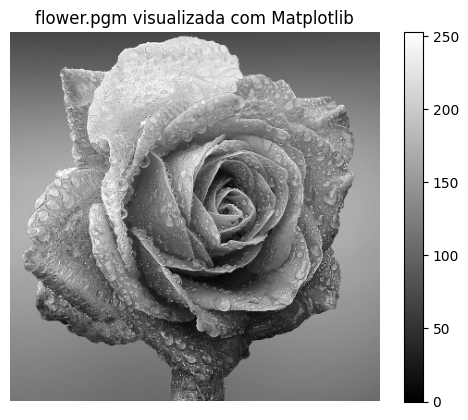

In [186]:
# 1. Lendo a imagem utilizando matplotlib.image
# Obs: A variável img_file foi criada no código anterior ao baixar a imagem
img_plt = mpimg.imread(img_file) 

# 2. Exibindo a imagem
# É utilizado o cmap='gray' para imagens monocromáticas. 
# Caso contrário, será aplicado um mapa de cores falso (geralmente esverdeado/amarelado chamado 'viridis').
plt.imshow(img_plt, cmap='gray')

# 3. Adicionando a barra de cores (colorbar) ao lado da imagem
plt.colorbar()

# 4. Removendo os eixos e mostrando o plot
plt.title("flower.pgm visualizada com Matplotlib")
plt.axis('off')
plt.show()

**c)** Usando atributos do tipo [`Image`](https://pillow.readthedocs.io/en/stable/reference/Image.html#image-attributes) da biblioteca `PIL`, tente responder as mesmas perguntas do item **a)**.

In [187]:
# Obtém o modo da imagem, que indica a classificação (tipo) e a profundidade
modo = img.mode
print(f"Modo da imagem: {modo}")

# Obtém as bandas (canais) presentes na imagem
bandas = img.getbands()
print(f"Bandas da imagem: {bandas}")

# Retorna uma tupla contendo o valor mínimo e máximo de intensidade do canal
min_val, max_val = img.getextrema()
print(f"Menor valor na imagem: {min_val}")
print(f"Maior valor na imagem: {max_val}")

Modo da imagem: L
Bandas da imagem: ('L',)
Menor valor na imagem: 0
Maior valor na imagem: 253


**1. Classificação e Profundidade da Imagem:**
A imagem é monocromática (tons de cinza) com profundidade de 8 bits.
*Justificativa:* O atributo img.mode retorna 'L' (Luminance), que é o padrão do PIL para imagens em tons de cinza de 8 bits. O método img.getbands() retorna ('L',), confirmando que existe apenas um único canal.

**2. Maior e menor valor de intensidade da imagem:**
*   **Menor valor:** 0
*   **Maior valor:** 253
*Justificativa:* O método img.getextrema() varre a imagem e retorna a tupla (0, 253), indicando os limites exatos dos valores presentes nos pixels.

### Exercício 1.2

Imagine que a imagem está um pouco clara demais e decido escurecê-la um pouco. Minha primeira ideia seria subtrair um valor de cada pixel, uma vez que valores menores correspondem a cores mais escuras. 

[[235 235 235 ... 241 240 240]
 [236 235 236 ... 241 241 241]
 [236 236 237 ... 241 241 242]
 ...
 [ 25  24  23 ...  14  14  13]
 [ 23  22  22 ...  13  13  13]
 [ 23  23  22 ...  13  13  13]]


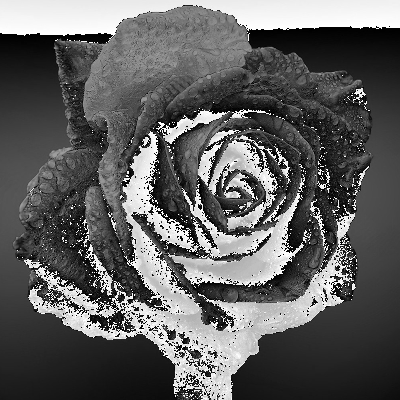

In [188]:
# Vou escurecer a imagem, subtraindo um valor dos pixels do array f.
g=f-93 
print(g)
# Agora vou transformar o array numa imagem PIL
g_img=Image.fromarray(g)
# E visualizar o resultado usando a função do PIL display
display(g_img)

**a)** Porque a imagem ficou mais clara ao invés de mais escura? Explique porque ao subtrair um determinado valor de intensidade da imagem original algumas regiões da imagem ficaram saturadas em branco.


**Resposta:**

A imagem ficou mais clara em algumas regiões devido a um problema de underflow (estouro de limite inferior) associado ao tipo de dado do array.

**Explicação:**
O array f é do tipo uint8 (inteiro sem sinal de 8 bits), o que significa que ele só consegue armazenar valores entre 0 e 255. 

Quando o valor 93 é subtraído de um pixel que originalmente possui um valor menor que 93 (por exemplo, o fundo escuro da imagem com valor 72), o resultado matemático seria negativo (-21). Como o formato uint8 não suporta números negativos, ocorre o *wrap-around* (o valor "dá a volta" pelo limite superior). 

Assim, a conta feita pelo computador é 256 - 21 = 235. Em vez de ficar mais escuro, o pixel salta para um valor de intensidade altíssimo (235), tornando a região super clara/branca. Pixels originais que eram maiores ou iguais a 93 não sofrem *underflow* e escurecem normalmente (ex: 118 - 93 = 25).

---
A principal mensagem é que podemos realizar operações quaisquer com os valores de pixel mas, no fim do dia, caso queiramos visualizar essas imagens, temos que pensar como esses valores serão mapeados para uma codificação que faça sentido no seu sistema computacional de apresentação.


**b)** Tente refazer esta mesma operação de "escurecimento" da imagem através de subtração, sem que esse efeito de saturação aconteça. Comente os métodos utilizados.

<details>
<summary>Dicas</summary>

- [numpy.clip](https://numpy.org/doc/stable/reference/generated/numpy.clip.html)

</details>

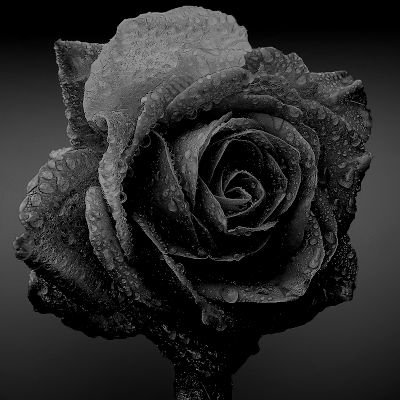

In [189]:
# Converte temporariamente para int16 (suporta negativos), subtrai 93 e aplica o np.clip
# O np.clip força valores menores que 0 a virarem 0 e maiores que 255 a virarem 255
g_corrigido = np.clip(f.astype(np.int16) - 93, 0, 255)

# Retorna o array para o formato original sem sinal (uint8)
g_corrigido = g_corrigido.astype(np.uint8)

# Transforma em imagem PIL e visualiza o resultado
g_img_corrigido = Image.fromarray(g_corrigido)
display(g_img_corrigido)

**Método utilizado para evitar a saturação (underflow):**

1. Conversão de Tipo (astype(np.int16)): O array f foi convertido temporariamente de uint8 (sem sinal) para int16 (com sinal). Isso permitiu que a subtração gerasse números negativos reais (ex: 72 - 93 = -21) em vez de dar a volta no limite do byte e gerar um falso número positivo alto.
2. Limitação (np.clip(..., 0, 255)): A função clip varre o array e "corta" qualquer valor fora do intervalo especificado. Todos os valores negativos (que gerariam o clarão branco no erro anterior) foram travados em 0 (preto absoluto).
3. Retorno ao formato original (astype(np.uint8)): Com os valores devidamente limitados entre 0 e 255, o array foi convertido de volta com segurança para uint8, formato esperado para a renderização correta da imagem.

## Parte 2 - Transformação de Intensidade

Tranformações de intensidade ou transformações rediométricas alteram o valor do pixel aplicando-se uma função ou tabela de mapeamento. Para entender como isso é implementado na prática, estudem atentamente o tutorial sobre ["Transformações de intensidade"](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/tutorial_ti_2.ipynb).

[[ 72  72  72 ...  78  77  77]
 [ 73  72  73 ...  78  78  78]
 [ 73  73  74 ...  78  78  79]
 ...
 [118 117 116 ... 107 107 106]
 [116 115 115 ... 106 106 106]
 [116 116 115 ... 106 106 106]]


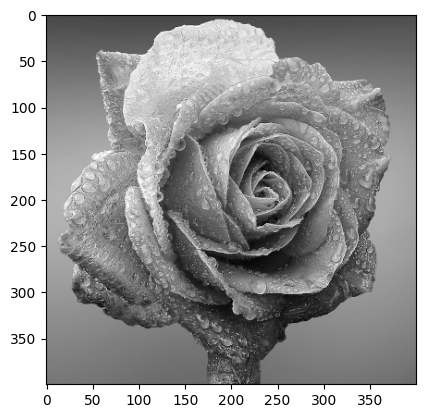

In [190]:
print(f)
plt.imshow(f,cmap='gray')

Vamos exercitar a aplicação de um mapeamento f = T[f] a partir de uma função de transformação T. No nosso caso, a função T será o negativo da imagem.

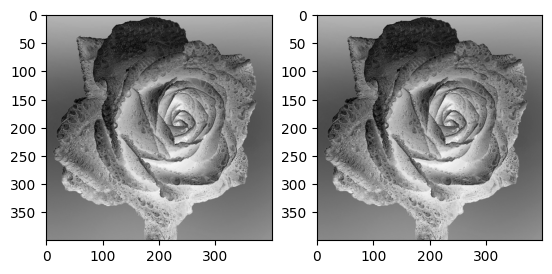

In [191]:
T = np.arange(256).astype('uint8')        # função identidade
T1 = 255 - T                              # criando a função negação a partir da identidade
#print(T1)
T2 = np.arange(255,-1,-1).astype('uint8') # criando diretamente a função negação
#print(T2)

plt.subplot(1,2,1)
f1 = T1[f]
plt.imshow(f1,cmap='gray')
plt.subplot(1,2,2)
f2 = T2[f]
plt.imshow(f2,cmap='gray')


### Exercício 2.1

Utilize transformações radiométricas para transformar a imagem e identificar o número da placa do carro apresentado na imagem abaixo. Explique seu raciocínio para chegar na solução.

float32


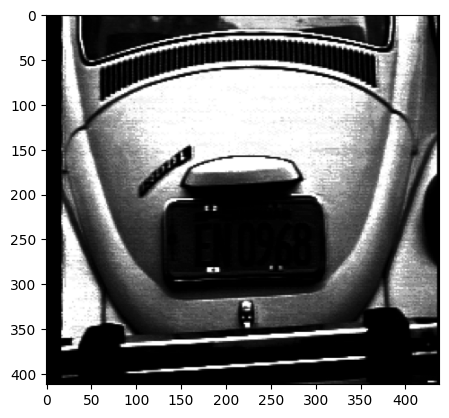

In [192]:
fusca_url = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/fusca.png"
f = mpimg.imread(download_image(fusca_url))  
plt.imshow(f,cmap='gray')
print(f.dtype)

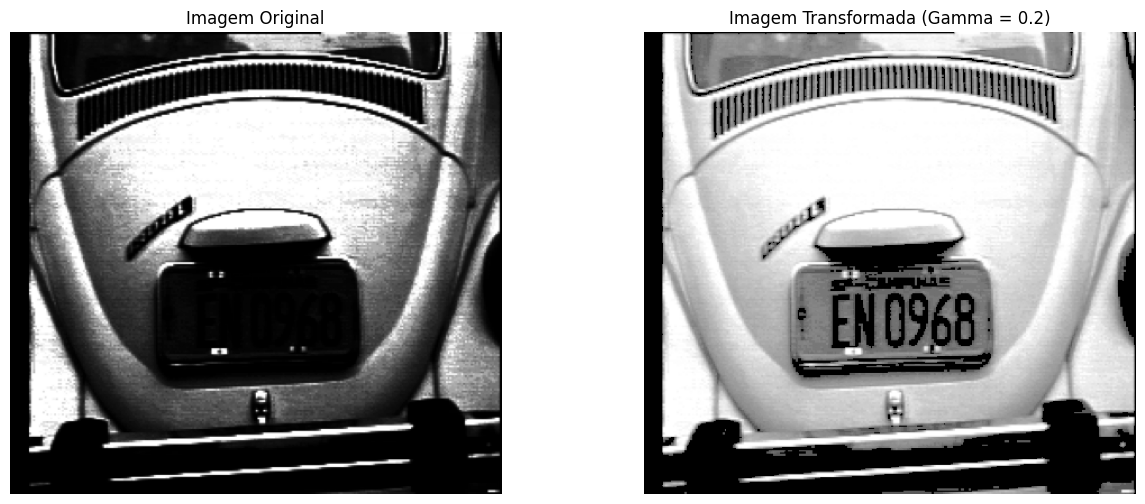

In [193]:
import numpy as np
import matplotlib.pyplot as plt

# Aplicando uma Transformação de Potência (Correção Gamma)
# A fórmula é: s = c * (r ** gamma)
# Usaremos um gamma menor que 1 para expandir os tons escuros
gamma = 0.2 
f_transformada = np.power(f, gamma)

# Plotando os resultados lado a lado para comparação
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

axs[0].imshow(f, cmap='gray')
axs[0].set_title('Imagem Original')
axs[0].axis('off')

axs[1].imshow(f_transformada, cmap='gray')
axs[1].set_title(f'Imagem Transformada (Gamma = {gamma})')
axs[1].axis('off')

plt.show()

### Explicação e Raciocínio

Raciocínio utilizado:

1. Análise do Problema: Ao observar a imagem original, nota-se que a região de interesse (a placa do carro) está na sombra. Isso significa que os pixels que compõem as letras e os números possuem valores de intensidade muito baixos (muito próximos de zero/preto), dificultando a distinção pelo olho humano.
2. Escolha da Transformação: Precisamos de uma transformação radiométrica que "estique" os valores baixos de intensidade, clareando as partes escuras da imagem sem nos importarmos se as partes que já eram claras (a lataria do carro) ficarem saturadas (brancas).
3. Aplicação: A Transformação de Potência (Correção Gamma) é ideal para isso. A função é definida como $s = r^\gamma$. 
   * Quando utilizamos um valor de $\gamma < 1$ (no código, usamos 0.2), a curva de transformação mapeia uma faixa muito estreita de valores escuros da entrada para uma faixa muito ampla de valores mais claros na saída.
   * Isso "puxa" os detalhes escondidos nas sombras para tons de cinza médios, revelando nitidamente os caracteres da placa (**EN 0968**), enquanto sacrifica o contraste da lataria do fusca (que fica "estourada"/branca, mas que não era o nosso alvo de interesse).

### Exercício 2.2

Uma das possíveis aplicações das transformações radiométricas é a segmentação de imagens, onde destacamos um objeto de interesse dos demais objetos (ou do fundo). 

**a)** A imagem abaixo mostra duas bolachas. Escolha um valor de limiar (threshold) para separar a bolacha do fundo da imagem. Crie uma função de transformação T e aplique esta transformação para obter os objetos de interesse (bolachas) pintados de branco e o fundo em preto. Comente os métodos utilizados.

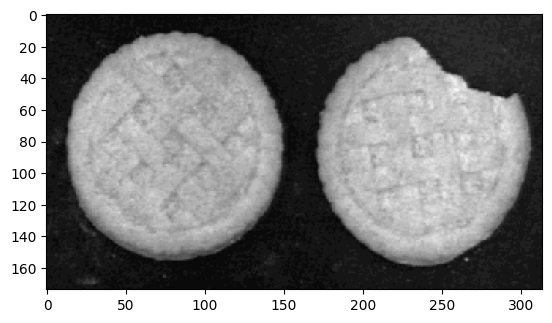

In [194]:
cookies_url = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/cookies.pgm"
plt.subplot(111)  
f = mpimg.imread(download_image(cookies_url))  
plt.imshow(f,cmap='gray')

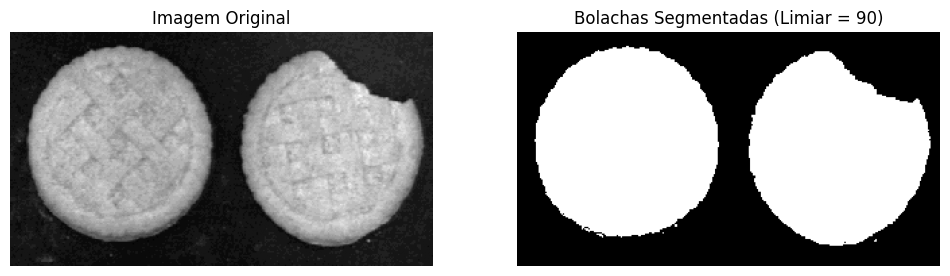

In [195]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definindo o valor do limiar (threshold)
# Após analisar os tons de cinza, um valor em torno de 90 separa bem o objeto do fundo
limiar = 90 

# 2. Criando a função de transformação T (Tabela de Mapeamento)
# Inicializa um array de 256 posições (0 a 255) preenchido com 0 (preto)
T = np.zeros(256, dtype=np.uint8)

# Atribui o valor 255 (branco) para todos os índices maiores ou iguais ao limiar
T[limiar:] = 255 

# Garantindo que a imagem base seja uint8 para servir de índice na tabela T
if f.dtype != np.uint8:
    f_uint8 = f.astype(np.uint8)
else:
    f_uint8 = f

# 3. Aplicando a transformação radiométrica na imagem
f_segmentada = T[f_uint8]

# Plotando os resultados para comparação
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(f, cmap='gray')
axs[0].set_title('Imagem Original')
axs[0].axis('off')

axs[1].imshow(f_segmentada, cmap='gray')
axs[1].set_title(f'Bolachas Segmentadas (Limiar = {limiar})')
axs[1].axis('off')

plt.show()

**Método utilizado: Limiarização (Thresholding) por Tabela de Mapeamento (LUT)**

*   **Lógica do Limiar:** Observando a imagem, as bolachas são substancialmente mais claras (possuem níveis de intensidade maiores) do que o fundo escuro. Escolhendo um valor de corte (limiar) intermediário, como 90, podemos separar essas duas classes.
*   **Função de Transformação $T$:** A forma mais eficiente de aplicar transformações pontuais é criar uma matriz de 256 posições chamada LUT (Look-Up Table). No código, os índices de 0 a 89 receberam o valor 0 (preto), e os índices de 90 a 255 receberam o valor 255 (branco). 
*   **Aplicação ($T[f]$):** Quando executamos o comando T[f], o NumPy varre a imagem original f. O valor de cada pixel atua como um índice que busca o novo valor na tabela T. Como resultado, todo o fundo colapsa para a cor preta absoluta e toda a área da bolacha salta para a cor branca absoluta de forma instantânea e otimizada.

### Exercício 2.3 

In [196]:
orquidea_url = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/orquideafeec-calua.jpg"
download_image(orquidea_url)

'orquideafeec-calua.jpg'

Leia e apresente a imagem `orquideafeec-calua.jpg`. Execute processamentos de intensidade nas diferentes bandas da imagem (R, G, B). Comente os métodos utilizados e resultados obtidos. É possível segmentar a flor da orquídea usando uma única banda de cor?

Dica: exemplos disponíveis em [Applying point transforms e Processing individual bands](https://pillow.readthedocs.io/en/stable/handbook/tutorial.html#image-enhancement).

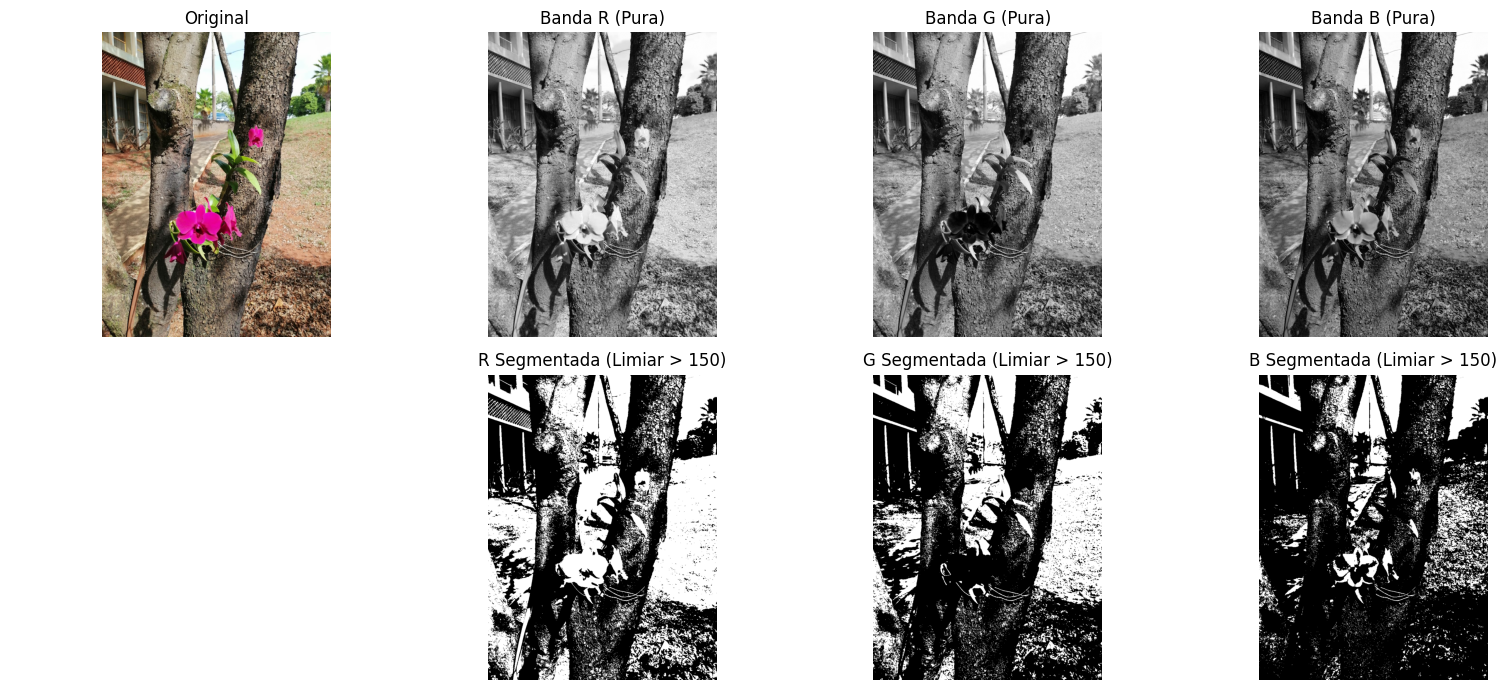

In [197]:
from PIL import Image
import matplotlib.pyplot as plt

# 1. Lendo a imagem original
img_orquidea = Image.open('orquideafeec-calua.jpg')

# 2. Separando as bandas (canais de cor: R, G, B)
banda_R, banda_G, banda_B = img_orquidea.split()

# 3. Aplicando a transformação de intensidade (Limiarização)
# O método point() avalia cada pixel através de uma função (aqui usamos lambda)
# Vamos testar o mesmo limiar (ex: 150) para todas as bandas para ver qual isola a flor
limiar = 150 

R_seg = banda_R.point(lambda p: 255 if p > limiar else 0)
G_seg = banda_G.point(lambda p: 255 if p > limiar else 0)
B_seg = banda_B.point(lambda p: 255 if p > limiar else 0)

# 4. Plotando os resultados para análise visual
fig, axs = plt.subplots(2, 4, figsize=(16, 7))

# Linha 1: Imagem original e as 3 bandas puras (em escala de cinza)
axs[0,0].imshow(img_orquidea)
axs[0,0].set_title('Original'); axs[0,0].axis('off')

axs[0,1].imshow(banda_R, cmap='gray')
axs[0,1].set_title('Banda R (Pura)'); axs[0,1].axis('off')

axs[0,2].imshow(banda_G, cmap='gray')
axs[0,2].set_title('Banda G (Pura)'); axs[0,2].axis('off')

axs[0,3].imshow(banda_B, cmap='gray')
axs[0,3].set_title('Banda B (Pura)'); axs[0,3].axis('off')

# Linha 2: Resultado da segmentação em cada banda
axs[1,0].axis('off') # Deixa o primeiro quadro em branco para alinhamento

axs[1,1].imshow(R_seg, cmap='gray')
axs[1,1].set_title('R Segmentada (Limiar > 150)'); axs[1,1].axis('off')

axs[1,2].imshow(G_seg, cmap='gray')
axs[1,2].set_title('G Segmentada (Limiar > 150)'); axs[1,2].axis('off')

axs[1,3].imshow(B_seg, cmap='gray')
axs[1,3].set_title('B Segmentada (Limiar > 150)'); axs[1,3].axis('off')

plt.tight_layout()
plt.show()

**1. Métodos utilizados:**
*   **Separação de Canais (split):** Dividiu a imagem colorida em três imagens independentes em tons de cinza, representando a intensidade pura do Vermelho (R), Verde (G) e Azul (B).
*   **Transformação de Intensidade (point e lambda):** O método .point() do PIL aplica uma operação ponto-a-ponto extremamente rápida. Usamos uma função anônima (lambda p: 255 if p > limiar else 0) para binarizar cada pixel: se for maior que o limiar estabelecido, vira branco (flor); caso contrário, vira preto (fundo).

**2. Resultados obtidos e segmentação com uma única banda:**
*   **Sim, é possível segmentar a orquídea usando a banda Vermelha (R).**
*   **Por que a Banda R funciona?** Como a orquídea possui tons quentes (rosa/magenta/lilás) e o fundo é composto majoritariamente por folhas verdes e galhos escuros, a flor reflete muita luz no canal vermelho, enquanto o fundo quase não reflete nada nesse canal. 
*   Ao observar as bandas puras impressas pelo código, a flor aparece muito brilhante na Banda R e o fundo muito escuro. Isso torna a segmentação simples: basta aplicar um *threshold* (limiar) na Banda R e a flor se destaca perfeitamente em branco, separada do fundo preto. Já nas bandas G e B, há um "borrão" visual de intensidades entre as folhas e a flor, inviabilizando uma segmentação tão limpa.

## Parte 3 - Contando moedas em uma imagem (opicional para EA979)

In [198]:
url_base = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/{value}.jpg"
values = [75, 80, 95]

filenames = []

for value in values:
    url = url_base.format(value=value)
    filename = download_image(url)
    filenames.append(filename)

Observe atentamente e tente entender os códigos abaixo, que aplicam diversas funções e conceitos para obter o valor total de um conjunto de moedas (de 5, 10 ou 25 centavos) presentes em uma imagem. De maneira geral, foram utilizadas funções de limiarização, obtenção de componentes conexos e morfologia matemática.

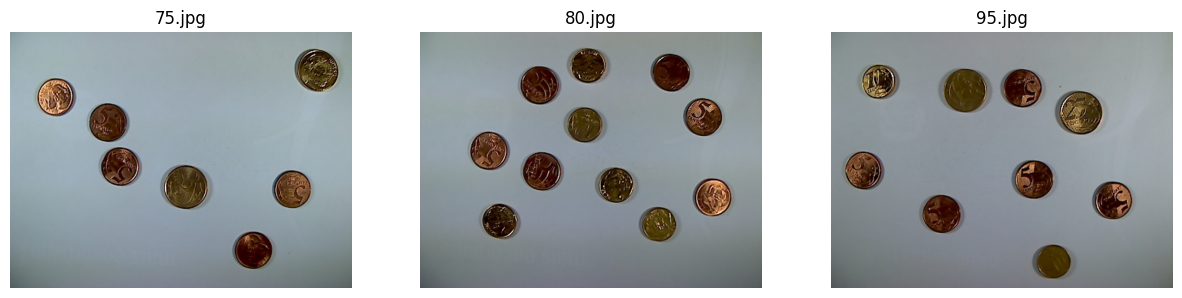

In [199]:
fig, axs = plt.subplots(1,3,figsize=(15, 6))

for i, file in enumerate(filenames):
  plt.subplot(1,3,1+i)
  plt.axis('off')
  plt.title(file)
  img = mpimg.imread(file)
  plt.imshow(img)

In [200]:
import cv2

def seg_and_postprocessing(img, k_cl, k_op):
    binr = cv2.threshold(255 - img, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]

    kernel_cl = np.ones((k_cl, k_cl), np.uint8) 
    kernel_op = np.ones((k_op, k_op), np.uint8) 
    
    close = cv2.morphologyEx(binr, cv2.MORPH_CLOSE, kernel_cl, iterations=1) 
    open = cv2.morphologyEx(close, cv2.MORPH_OPEN, kernel_op, iterations=1)

    plt.figure(figsize=(12,6))
    plt.subplot(1,3,1)
    plt.imshow(binr, cmap='gray')
    plt.axis('off')
    plt.subplot(1,3,2)
    plt.imshow(close, cmap='gray')
    plt.axis('off')
    plt.subplot(1,3,3)
    plt.imshow(open, cmap='gray')
    plt.axis('off')
    plt.show()

    return open

ModuleNotFoundError: No module named 'cv2'

In [ ]:
def calc_npixels_label(img, n_labels):
    list_npixels = []
    for v in range(n_labels-1):
        npixels = (img[img == v+1]//(v+1)).sum()
        list_npixels.append(npixels)
    return list_npixels

In [ ]:
for i, file in enumerate(filenames):
  img = mpimg.imread(file).astype('uint8')
  img_gray = np.uint8(0.3*img[:,:,0]+0.59*img[:,:,1]+0.11*img[:,:,2])

  seg_img = seg_and_postprocessing(img_gray, 15, 31)
  output = cv2.connectedComponentsWithStats(seg_img, 4)

  plt.figure(figsize=(8,4))
  plt.subplot(1,2,1)
  plt.imshow(output[1])
  plt.axis('off')

  list_npixels = calc_npixels_label(output[1], output[0])

  soma = 0
  for n, p in enumerate(list_npixels):
    x = int(output[3][n+1][0])
    y = int(output[3][n+1][1])

    if p < 3500:
      soma += 10
      cv2.putText(img, '10', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    elif p > 4600:
      soma += 25
      cv2.putText(img, '25', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    else:
      soma += 5
      cv2.putText(img, '5', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.axis('off')
  plt.show()

  print('Imagem', file)
  print('Número de moedas', len(list_npixels))
  print(list_npixels)
  print('Valor total:', soma)
  print()

### Exercício 3.1

Utilizando como base os códigos apresentados anteriormente, crie um novo Notebook que seja uma demonstração (demo) de como obter o valor total de um conjunto de moedas em uma imagem. O Notebook deve conter uma breve descrição do problema e deve explicar passo a passo as etapas e códigos utilizados para chegar ao resultado final. Tente descrever e exemplificar cada etapa, indicando qual o seu objetivo, explicando os processamentos aplicados, as funções utilizadas e os parâmetros escolhidos. Ao final do Notebook, apresente links para referências úteis no aprofundamento dos tópicos abordados. Você também pode linkar referências interessantes ao longo do Notebook, à medida que apresenta as etapas e os conceitos relacionados.

Não se esqueça de enviar o Notebook da demo juntamente com a entrega deste Notebook!